In [167]:
import doralite
import gfdl_utils.core as gu
import CM4Xutils

In [168]:
pp = CM4Xutils.pp_dict["CM4Xp125"]["piControl"]
allvars = gu.get_allvars(pp)

In [169]:
allvars["ocean_annual_rho2"]

['thkcello', 'uhml', 'umo', 'vhml', 'vmo', 'volcello']

In [170]:
import xarray as xr

### Flawed density bins

In [171]:
ds_tmp = xr.open_zarr("../data/interim/CM4Xp125_historical_transient_tracers.zarr/")

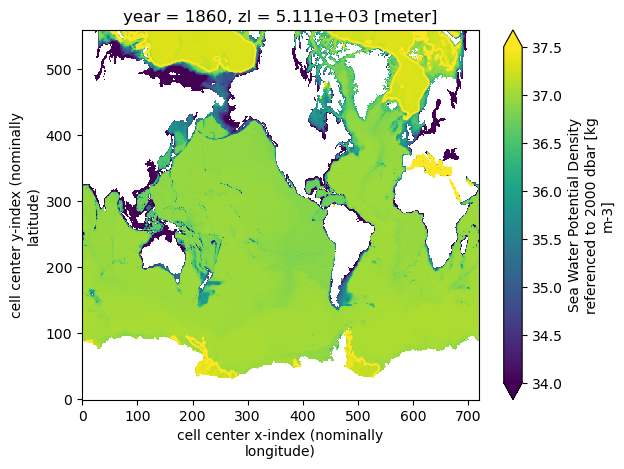

In [172]:
ds_tmp["sigma2"].isel(year=0, zl=-1).plot(vmin=34, vmax=37.5)
ds_tmp["sigma2"].isel(year=10, zl=-1).plot.contour(levels=[37.0755])

### Correct density bins

In [ ]:
import warnings

import doralite
import gfdl_utils.core as gu
import CM4Xutils
import numpy as np
import xarray as xr
import xgcm

import gsw, xwmt
import zarr
import cftime
import gsw
import dask

import os
import sys

In [192]:
model = "CM4Xp125"
#model = sys.argv[1]
testing = False

print(f"Subsample {model} transient tracer output.")
dim_coarsen_dict = {"CM4Xp25": {"X":2, "Y":2}, "CM4Xp125": {"X":4, "Y":4}}
dim_coarsen = dim_coarsen_dict[model]
odivs = CM4Xutils.exp_dict[model]

def load_tracer(exp, tracers, t="*"):
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_inert_month"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, tracers, dmget=True, engine='netcdf4', chunks={})
    chunks = {'zl':75}
    ds = ds.chunk(chunks)
    
    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)
    
    return ds

def load_state(exp, t="*"):
    state_vars = ["thkcello", "thetao", "so", "col_height"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_annual"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'zl':75}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)
    ds = add_estimated_layer_interfaces(ds)

    grid = CM4Xutils.ds_to_grid(ds)
    
    # Compute potential density
    diagnose_sigma2(grid)
    infer_z(grid)
    
    return grid._ds

def assign_historical_dates(ds_ctrl):
    # Align dates of a control simulation (with nominal dates starting from year 1)
    # to a historically-referenced simulation (e.g. with dates starting from 1850)
    year_ctrl = ds_ctrl.year.copy()
    ds_ctrl = ds_ctrl.rename({"year": "year_ctrl"})
    historical_equivalent_dates = xr.DataArray(
        np.array([y+1749 for y in year_ctrl]),
        dims=("year_ctrl",)
    )
    ds_ctrl = (
        ds_ctrl
        .assign_coords({"year": historical_equivalent_dates})
        .swap_dims({"year_ctrl": "year"})
    )
    
    return ds_ctrl

def add_estimated_layer_interfaces(ds):
    return ds.assign_coords({"zi": xr.DataArray(
        np.concatenate([[0], 0.5*(ds.zl.values[1:]+ds.zl.values[0:-1]), [6000]]),
        dims=('zi',)
    )})

def diagnose_sigma2(grid):
    grid._ds["sigma2"] = xr.apply_ufunc(
        gsw.sigma2,
        grid._ds.so,
        grid._ds.thetao,
        dask="parallelized"
    ).rename("sigma2")
    grid._ds["sigma2"].attrs = {
        'long_name': 'Sea Water Potential Density referenced to 2000 dbar',
        'units': 'kg m-3',
        'cell_methods': 'area:mean z_l:mean yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
        'standard_name': 'sea_water_potential_density'
    }

def infer_z(grid):
    zl = grid.axes['Z'].coords['center']
    zi = grid.axes['Z'].coords['outer']
    print(zl, zi)
    
    grid._ds["z_i"] = (
        ((grid._ds.col_height - grid._ds.deptho) - grid.cumsum(grid._ds.thkcello, "Z", to="outer", boundary="extend"))
        .transpose("time", zi, "yh", "xh")
    ).chunk({zi: grid._ds[zi].size})
    grid._ds["z_i"].attrs = {
        'long_name': 'depth of layer interfaces',
        'units': 'm',
        'cell_methods': 'area:mean zi:point yh:mean xh:mean time: mean',
        'cell_measures': 'area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }
    
    zl_extended = np.concatenate((
        grid._ds[zi][np.array([0])].values,
        grid._ds[zl].values,
        grid._ds[zi][np.array([-1])].values
    ))

    thkcello_i = grid.transform(
        grid._ds["thkcello"].fillna(0.),
        "Z",
        zl_extended,
        method="conservative",
    ).assign_coords({zi:grid._ds[zi].values}).transpose("time", zi, "yh", "xh")

    # CM4Xp25 does not have col_height variable available, so need to compute from thkcello
    if "col_height" not in grid._ds.data_vars:
        grid._ds["col_height"] = grid._ds["thkcello"].sum("zl")
        grid._ds["col_height"].attrs = {
            'long_name': 'The height of the water column',
             'units': 'm',
             'cell_methods': 'area:mean yh:mean xh:mean time: mean',
             'cell_measures': 'area: areacello',
             'time_avg_info': 'average_T1,average_T2,average_DT'
        }
    
    grid._ds["z_l"] = (
        ((grid._ds.col_height - grid._ds.deptho) - grid.cumsum(thkcello_i, "Z", to="center"))
        .transpose("time", zl, "yh", "xh")
    ).chunk({zl: grid._ds[zl].size})
    grid._ds["z_l"].attrs = {
        'long_name': 'depth of layer centers',
        'units': 'm',
        'cell_methods': 'area:mean zl:point yh:mean xh:mean time: mean',
        'cell_measures': 'volume: volcello area: areacello',
        'time_avg_info': 'average_T1,average_T2,average_DT',
    }

def load(exp, tracers, t="*"):
    try:
        ds_tracer = (
            load_tracer(exp, tracers, t=t)
            .groupby("time.year").mean()
            .drop_vars("average_DT")
        )
    except:
        ds_tracer = xr.Dataset()
    ds_thickness = (
        load_state(exp, t=t)
        .groupby("time.year").mean()
        .drop_vars("average_DT")
    )
    
    ds = xr.merge([ds_tracer, ds_thickness], compat="override")
    
    grid = CM4Xutils.ds_to_grid(ds)
    
    return grid

Subsample CM4Xp125 transient tracer output.


In [194]:
def load_rho2(exp, t="*"):
    # Load thickness of density layers
    state_vars = ["thkcello"]
    meta = doralite.dora_metadata(exp)
    pp = meta['pathPP']
    ppname = "ocean_month_rho2"
    out = "ts"
    local = gu.get_local(pp, ppname, out)
    ds = gu.open_frompp(pp, ppname, out, local, t, state_vars, dmget=True, engine='netcdf4', chunks={})
    chunks = {'rho2_l':74}
    ds = ds.chunk(chunks)

    og = gu.open_static(pp, ppname)
    model = [e for e,d in CM4Xutils.exp_dict.items() for k,v in d.items() if exp==v][0]
    sg = xr.open_dataset(CM4Xutils.exp_dict[model]["hgrid"])
    og = CM4Xutils.fix_geo_coords(og, sg)
    ds = CM4Xutils.add_grid_coords(ds, og)

    grid = CM4Xutils.ds_to_grid(ds)

    # Get depths of density interfaces
    grid._ds["zrho2_i"] = grid.cumsum(
        grid._ds.thkcello,
        "Z",
        to="outer",
        boundary="extend"
    ).chunk({"rho2_i":75})

    return grid

In [195]:
exp = CM4Xutils.exp_dict["CM4Xp125"]["piControl"]

In [196]:
ds = load_state(exp, t="0451*")

Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: native `z`
zl zi


/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/transform.py:245: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  out = xr.apply_ufunc(


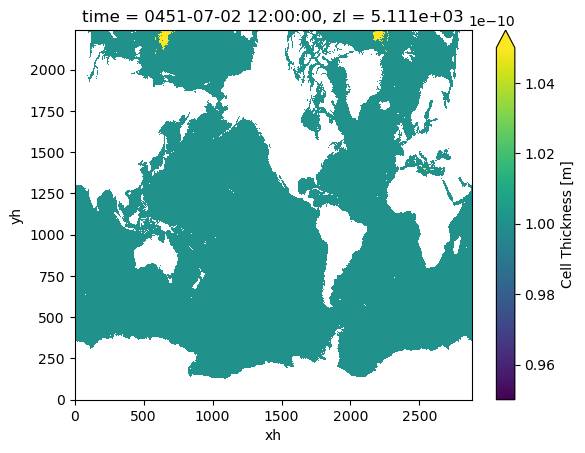

In [202]:
ds.thkcello.isel(zl=-1, time=0).plot(robust=True)

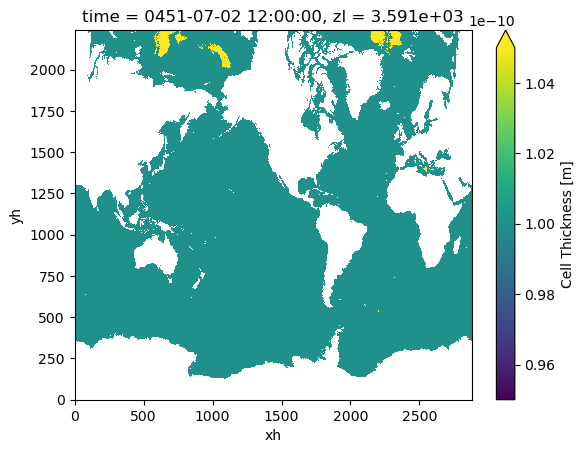

In [203]:
ds.thkcello.isel(zl=-2, time=0).plot(robust=True)

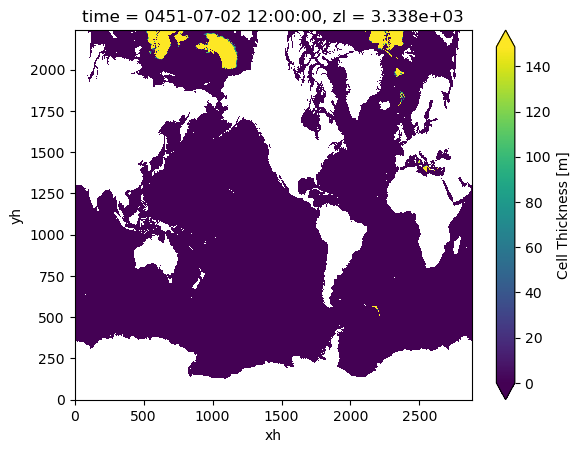

In [204]:
ds.thkcello.isel(zl=-3, time=0).plot(robust=True)

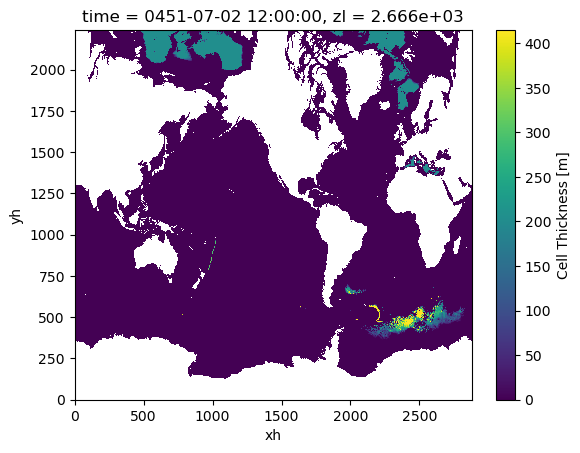

In [208]:
ds.thkcello.isel(zl=-6, time=0).plot()

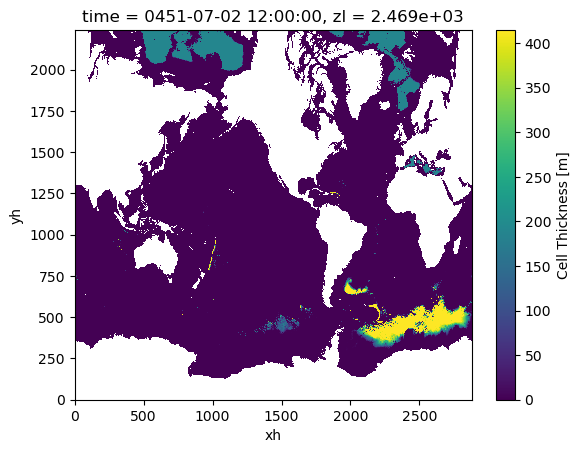

In [209]:
ds.thkcello.isel(zl=-7, time=0).plot()

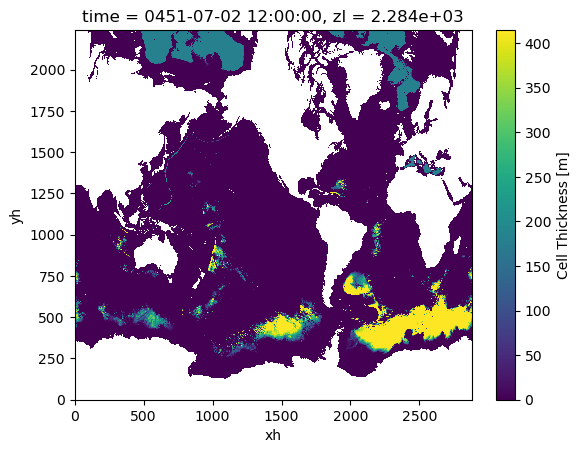

In [210]:
ds.thkcello.isel(zl=-8, time=0).plot()

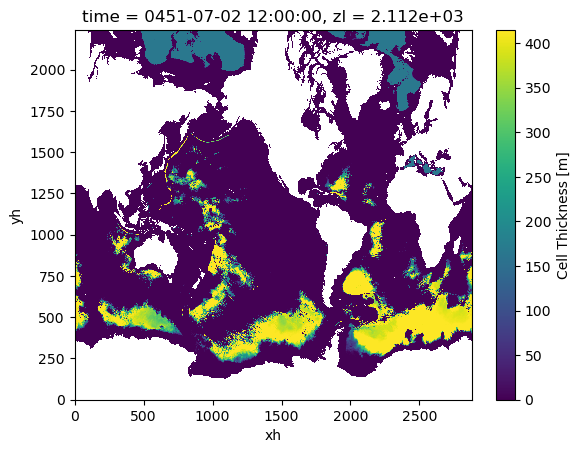

In [211]:
ds.thkcello.isel(zl=-9, time=0).plot()

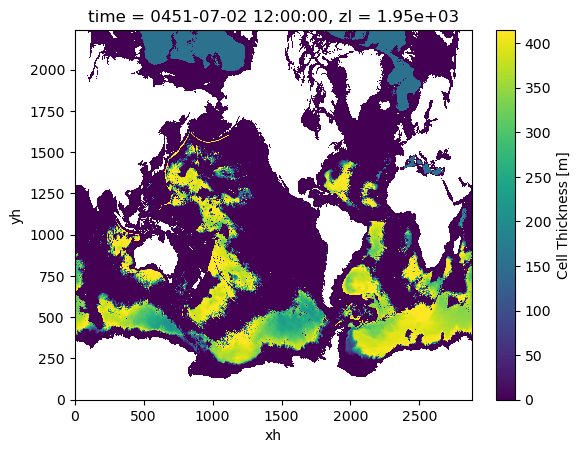

In [212]:
ds.thkcello.isel(zl=-10, time=0).plot()

In [197]:
grid = load_rho2(exp, t="*0451*")

Issuing dmget command to migrate data to disk. Migration complete.
Inferring Z grid coordinate: density `rho2`


In [198]:
tmp = grid.transform(
    grid._ds.thkcello,
    "Z",
    target=ds.z_i,
    target_data=grid._ds.zrho2_i,
    method="conservative"
)

ValueError: Cant infer `target_dim` from `target` since it has more than 1 dimension [('time', 'zi', 'yh', 'xh')]. This is currently not supported. `.

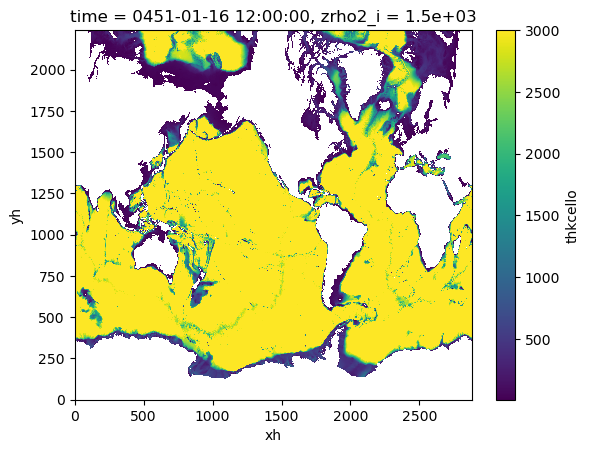

In [165]:
tmp.isel(time=0, zrho2_i=0).plot()

In [152]:
import gsw, xwmt, xhistogram

In [151]:
tmp = xhistogram.xarray.histogram(
    grid._ds.zrho2_i,
    bins=[0, 700, 3000, 6000],
    dim=("zl",),
    weights=grid._ds.rho2_l*grid._ds.thkcello.fillna(0.)*grid._ds.areacello.fillna(0.),
    bin_dim_suffix="_l",
    # TEMPORARY FIX FOR https://github.com/xgcm/xhistogram/issues/16
    block_size=None
)

<xarray.DataArray 'rho2_l' (rho2_l: 74)> Size: 592B
array([1004.24625, 1013.565  , 1017.71   , 1021.855  , 1025.96375, 1028.165  ,
       1028.495  , 1028.83   , 1029.165  , 1029.495  , 1029.83   , 1030.165  ,
       1030.495  , 1030.83   , 1031.165  , 1031.495  , 1031.83   , 1032.165  ,
       1032.495  , 1032.83   , 1033.0665 , 1033.28225, 1033.571  , 1033.8425 ,
       1034.09975, 1034.3435 , 1034.5735 , 1034.7895 , 1034.991  , 1035.17725,
       1035.348  , 1035.5035 , 1035.64475, 1035.77275, 1035.8885 , 1035.99375,
       1036.09025, 1036.17925, 1036.262  , 1036.34   , 1036.4145 , 1036.4865 ,
       1036.5565 , 1036.625  , 1036.692  , 1036.75525, 1036.812  , 1036.86125,
       1036.904  , 1036.9415 , 1036.974  , 1037.002  , 1037.02625, 1037.0475 ,
       1037.0665 , 1037.08375, 1037.1    , 1037.116  , 1037.132  , 1037.148  ,
       1037.164  , 1037.18   , 1037.1965 , 1037.2145 , 1037.235  , 1037.26   ,
       1037.2945 , 1037.345  , 1037.415  , 1037.5075 , 1037.625  , 1037.76   ,
       1037.9    , 1038.485  ])
Coordinates:
  * rho2_l   (rho2_l) float64 592B 1.004e+03 1.014e+03 ... 1.038e+03 1.038e+03
Attributes:
    long_name:  Target Potential Density at cell center
    units:      kg m-3
    axis:       Z
    positive:   down
    edges:      rho2_i

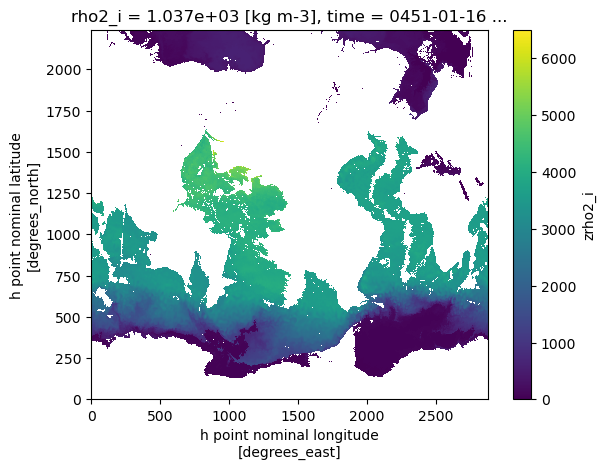

In [149]:
grid._ds.zrho2_i.isel(time=0, rho2_i=-20).plot()

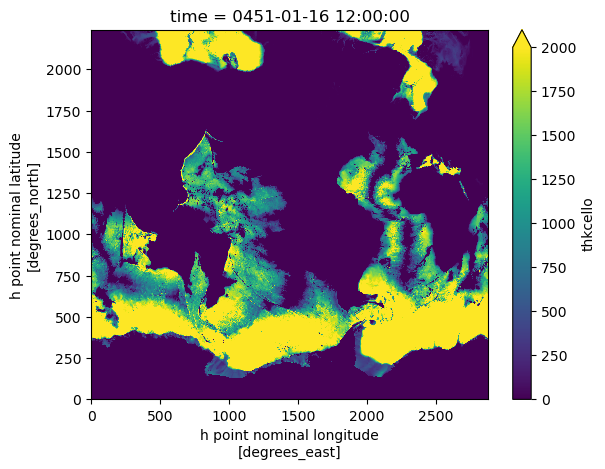

In [98]:
ds.thkcello.isel(time=0).sel(rho2_l=slice(1037.0755, None)).sum("rho2_l").plot(vmin=0, vmax=2000)

<xarray.Dataset> Size: 115GB
Dimensions:     (time: 60, nv: 2, rho2_i: 75, rho2_l: 74, yh: 2240, xh: 2880,
                 yq: 2241, xq: 2881)
Coordinates: (12/25)
  * nv          (nv) float64 16B 1.0 2.0
  * rho2_i      (rho2_i) float64 600B 997.0 1.011e+03 ... 1.038e+03 1.039e+03
  * rho2_l      (rho2_l) float64 592B 1.004e+03 1.014e+03 ... 1.038e+03
  * time        (time) object 480B 0451-01-16 12:00:00 ... 0455-12-16 12:00:00
    dxCv        (xh, yq) float32 26MB 1.711e+03 1.721e+03 ... 6.08e+03 6.08e+03
    dyCu        (xq, yh) float32 26MB 3.844e+03 3.84e+03 ... 0.02469 0.02469
    ...          ...
    geolon_c    (yq, xq) float64 52MB -298.6 -298.5 -298.4 ... 60.0 60.0 60.0
    geolat_c    (yq, xq) float64 52MB -82.47 -82.47 -82.47 ... 64.14 64.09 64.03
    deptho      (yh, xh) float32 26MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    wet         (yh, xh) float32 26MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    wet_u       (yh, xq) float32 26MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    wet_v       (yq, xh) float32 26MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    average_DT  (time) timedelta64[ns] 480B dask.array<chunksize=(60,), meta=np.ndarray>
    average_T1  (time) object 480B dask.array<chunksize=(60,), meta=np.ndarray>
    average_T2  (time) object 480B dask.array<chunksize=(60,), meta=np.ndarray>
    thkcello    (time, rho2_l, yh, xh) float32 115GB dask.array<chunksize=(1, 9, 280, 360), meta=np.ndarray>
    time_bnds   (time, nv) object 960B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:            ocean_month_rho2.045101-045512.thkcello.nc
    title:               CM4_piControl_c192_OM4p125_v8
    associated_files:    areacello: 04510101.ocean_static.nc
    grid_type:           regular
    grid_tile:           N/A
    external_variables:  volcello areacello